# Redes Neurais com PyTorch

Este notebook serve como um guia introdutório ao desenvolvimento de redes neurais utilizando a biblioteca PyTorch. Abordaremos os componentes fundamentais da biblioteca, desde a manipulação de tensores até a construção e o treinamento de um modelo de rede neural para classificação de imagens.

## O Módulo `torch.nn`

O `torch.nn` é o módulo do PyTorch para a construção de redes neurais. Ele fornece um conjunto de blocos de construção, como camadas (`Layers`), funções de ativação (`Activation Functions`), funções de custo (`Loss Functions`) e contêineres (`Containers`). Uma "camada" no `torch.nn` é um objeto que encapsula tanto os pesos (parâmetros) quanto as operações a serem aplicadas nos dados de entrada.

### Camada Linear: `nn.Linear`

A camada mais fundamental é a `nn.Linear`, que aplica uma transformação afim aos dados de entrada: $y = xW^T + b$.

-   `in_features`: a dimensionalidade do espaço de entrada.
-   `out_features`: a dimensionalidade do espaço de saída.

Os tensores de peso (`weight`, $W$) e de viés (`bias`, $b$) são encapsulados como `nn.Parameter`, uma subclasse de `torch.Tensor` que os registra automaticamente como parâmetros de um `nn.Module`.

In [17]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: cuda


In [ ]:
from torch import nn

# Definindo uma camada linear
# Entrada: 10 features
# Saída: 5 features
linear_layer = nn.Linear(in_features=10, out_features=5)

# Criando um tensor de entrada de exemplo (um "batch" com 3 amostras)
# O formato é (batch_size, in_features)
input_tensor = torch.randn(3, 10)

# Passando os dados pela camada
output_tensor = linear_layer(input_tensor)

print(f"Formato do tensor de entrada: {input_tensor.shape}")
print(f"Formato do tensor de saída: {output_tensor.shape}")
print(f"\nPesos (weights) da camada:\n {linear_layer.weight.shape}")
print(f"Viés (bias) da camada:\n {linear_layer.bias.shape}")

Formato do tensor de entrada: torch.Size([3, 10])
Formato do tensor de saída: torch.Size([3, 5])

Pesos (weights) da camada:
 torch.Size([5, 10])
Viés (bias) da camada:
 torch.Size([5])


## Funções de Ativação

Funções de ativação introduzem não linearidade no modelo, capacitando-o a aprender fronteiras de decisão complexas. Elas são aplicadas elemento a elemento na saída de uma camada.

### Funções Comuns

-   **Sigmoid**: Comprime os valores de entrada no intervalo $(0, 1)$. Utilizada historicamente em camadas ocultas e atualmente em camadas de saída para classificação binária.
    $$ \sigma(x) = \frac{1}{1 + e^{-x}} $$
-   **Tanh (Tangente Hiperbólica)**: Comprime os valores de entrada no intervalo $(-1, 1)$. Geralmente converge mais rápido que a Sigmoid por ser centrada em zero.
    $$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$
-   **ReLU (Rectified Linear Unit)**: A função de ativação mais utilizada em redes profundas. É computacionalmente eficiente e ajuda a mitigar o problema do desaparecimento do gradiente (vanishing gradient).
    $$ \text{ReLU}(x) = \max(0, x) $$
-   **Leaky ReLU**: Uma variação da ReLU que permite a passagem de um pequeno gradiente negativo, prevenindo o problema dos "neurônios mortos".
    $$ \text{LeakyReLU}(x) = \begin{cases} x, & \text{if } x > 0 \\ \alpha x, & \text{otherwise} \end{cases} $$
-   **Softmax**: Transforma um vetor de números reais (logits) em uma distribuição de probabilidade sobre múltiplas classes. Utilizada na camada de saída para classificação multiclasse.
    $$ \text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}} $$

In [4]:
# As funções de ativação também estão no módulo nn
relu_activation = nn.ReLU()
leaky_relu_activation = nn.LeakyReLU()

# Aplicando a ativação na saída da camada linear anterior
output_with_relu = relu_activation(output_tensor)
output_with_leaky_relu = leaky_relu_activation(output_tensor)

print(f"Saída da camada linear:\n {output_tensor}\n")
print(f"Saída após ativação ReLU:\n {output_with_relu}\n")
print(f"Saída após ativação Leaky ReLU:\n {output_with_leaky_relu}")

Saída da camada linear:
 tensor([[-0.8158, -0.9153, -0.5426,  0.4416,  0.9039],
        [-0.0223, -0.0735,  0.7892, -0.3315, -0.3108],
        [-0.1024,  0.1418,  0.1844, -0.8728, -0.3337]],
       grad_fn=<AddmmBackward0>)

Saída após ativação ReLU:
 tensor([[0.0000, 0.0000, 0.0000, 0.4416, 0.9039],
        [0.0000, 0.0000, 0.7892, 0.0000, 0.0000],
        [0.0000, 0.1418, 0.1844, 0.0000, 0.0000]], grad_fn=<ReluBackward0>)

Saída após ativação Leaky ReLU:
 tensor([[-8.1582e-03, -9.1528e-03, -5.4264e-03,  4.4163e-01,  9.0394e-01],
        [-2.2265e-04, -7.3544e-04,  7.8925e-01, -3.3154e-03, -3.1082e-03],
        [-1.0238e-03,  1.4180e-01,  1.8442e-01, -8.7281e-03, -3.3366e-03]],
       grad_fn=<LeakyReluBackward0>)


## Construindo Modelos

O PyTorch oferece duas maneiras principais de agrupar camadas para formar um modelo completo.

### `nn.Sequential`

`nn.Sequential` é um contêiner que recebe uma sequência de módulos (camadas, funções de ativação, etc.) e os executa na ordem em que são passados. É uma forma rápida e simples de criar modelos onde os dados fluem sequencialmente através das camadas.

In [5]:
# Construindo um modelo simples com nn.Sequential
# Input (784) -> Linear (128) -> ReLU -> Linear (10) -> Output
model_sequential = nn.Sequential(
    nn.Linear(in_features=784, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
)

# Criando um tensor de entrada de exemplo (batch com 64 imagens achatadas de 28x28)
# 28 * 28 = 784
input_images = torch.randn(64, 784)

# Forward pass através do modelo sequencial
logits = model_sequential(input_images) # 'logits' são as saídas brutas antes da probabilidade

print(f"Formato da saída do modelo: {logits.shape}")

Formato da saída do modelo: torch.Size([64, 10])


### Classes customizadas com `nn.Module`

Para modelos mais complexos, como aqueles com múltiplos caminhos de entrada/saída ou lógicas de *forward pass* não sequenciais (e.g., redes residuais), a abordagem recomendada é criar uma classe que herda de `nn.Module`.

Toda classe de modelo customizada deve:
1.  Herdar de `torch.nn.Module`.
2.  Definir as camadas no construtor `__init__(self)`.
3.  Implementar a lógica do *forward pass* no método `forward(self, x)`.

O método `backward()` é gerenciado automaticamente pelo `autograd`.

In [ ]:
# Definindo o mesmo modelo anterior, mas agora como uma classe
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.relu(out)
        out = self.layer2(out)
        return out

# Instanciando o modelo
model_class = NeuralNetwork(input_size=784, hidden_size=128, num_classes=10)

# O uso é idêntico
logits_class = model_class(input_images)

print(f"Formato da saída do modelo (classe): {logits_class.shape}")
print(f"\nEstrutura do modelo:\n{model_class}")

Formato da saída do modelo (classe): torch.Size([64, 10])

Estrutura do modelo:
NeuralNetwork(
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)


## Datasets e DataLoaders

Para treinar um modelo, precisamos de um pipeline de dados eficiente. O PyTorch oferece duas primitivas de dados fundamentais para isso: `torch.utils.data.Dataset` e `torch.utils.data.DataLoader`.

### A Estrutura de um `Dataset` Customizado

A classe `Dataset` é uma classe abstrata que representa uma fonte de dados. Para criar seu próprio dataset, você precisa herdar desta classe e sobrescrever três métodos especiais (métodos mágicos):

1.  `__init__(self, ...)`: O construtor da classe. É executado uma única vez ao instanciar o dataset. É aqui que você normalmente faria o carregamento inicial dos dados (ex: ler um arquivo CSV, encontrar os caminhos das imagens em um diretório).

2.  `__len__(self)`: Este método deve retornar o número total de amostras no seu dataset. O `DataLoader` utiliza essa informação para saber o tamanho do dataset e definir os índices.

3.  `__getitem__(self, idx)`: Este método é responsável por carregar e retornar **uma única amostra** do dataset, dado um índice `idx`. É aqui que transformações nos dados (como data augmentation ou normalização) são frequentemente aplicadas.

In [7]:
from torch.utils.data import Dataset

# Exemplo prático de um Dataset customizado com tensores
class SimpleTensorDataset(Dataset):
    def __init__(self, features_tensor, labels_tensor):
        self.features = features_tensor
        self.labels = labels_tensor

    def __len__(self):
        # Retorna o número total de amostras
        return self.features.size(0)

    def __getitem__(self, idx):
        # Retorna uma tupla (feature, label) para um dado índice
        feature_sample = self.features[idx]
        label_sample = self.labels[idx]
        return feature_sample, label_sample

# Criando dados de exemplo
features = torch.randn(500, 64) # 500 amostras, 64 features cada
labels = torch.randint(0, 2, (500,)) # 500 rótulos (0 ou 1)

# Instanciando o nosso dataset customizado
custom_dataset = SimpleTensorDataset(features, labels)

# Verificando a implementação dos métodos
print(f"Tamanho total do dataset: {len(custom_dataset)}")

Tamanho total do dataset: 500


In [8]:
# Pegando a primeira amostra (chamando __getitem__ com idx=0)
first_sample_features, first_sample_label = custom_dataset[0]
print(f"Primeira amostra (features): {first_sample_features.shape}")
print(f"Primeira amostra (label): {first_sample_label}")

Primeira amostra (features): torch.Size([64])
Primeira amostra (label): 0


### O Papel do `DataLoader`

Uma vez que temos um objeto `Dataset`, que sabe como acessar amostras individuais, precisamos de uma forma eficiente de iterar sobre ele durante o treinamento. É aqui que entra o `DataLoader`.

O `DataLoader` é um iterador que envolve um `Dataset` e automatiza o processo de criação de mini-lotes (*mini-batches*). Suas principais funcionalidades são:

-   **Agrupamento em Lotes (Batching)**: Agrupa múltiplas amostras retornadas pelo `__getitem__` do `Dataset` para formar um lote (batch) de dados.
-   **Embaralhamento (Shuffling)**: Permite embaralhar os dados a cada época (`shuffle=True`) para evitar que o modelo aprenda a ordem dos dados e melhore a generalização.
-   **Carregamento Paralelo (Parallel Loading)**: Pode usar múltiplos subprocessos (`num_workers`) para carregar os dados em paralelo, evitando que o carregamento de dados se torne um gargalo.

In [9]:
from torch.utils.data import DataLoader

# Agora, usamos o DataLoader com o 'custom_dataset' que criamos anteriormente
data_loader = DataLoader(dataset=custom_dataset, batch_size=10, shuffle=True)

# O DataLoader é um iterável. Podemos usá-lo em um laço 'for' ou com 'next(iter())'
# para obter o próximo lote de dados.
first_batch_features, first_batch_labels = next(iter(data_loader))

print(f"Formato do batch de features: {first_batch_features.shape}")
print(f"Formato do batch de rótulos: {first_batch_labels.shape}")

Formato do batch de features: torch.Size([10, 64])
Formato do batch de rótulos: torch.Size([10])


### Datasets Disponibilizados: `torchvision`

Compreendida a estrutura de um `Dataset` e o papel do `DataLoader`, podemos apreciar a conveniência de bibliotecas como a `torchvision`. Ela já fornece implementações prontas da classe `Dataset` para datasets populares como o MNIST, que seguem a mesma estrutura que acabamos de ver.

In [10]:
import torchvision
import torchvision.transforms as transforms

# Definindo transformações para os dados
# ToTensor() converte a imagem PIL (H x W x C) no intervalo [0, 255]
# para um FloatTensor (C x H x W) no intervalo [0.0, 1.0].
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Média e desvio padrão do MNIST
])

# Baixando o dataset de treino
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# Baixando o dataset de teste
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

In [11]:
# Criando os DataLoaders
batch_size = 128
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Iterando sobre o DataLoader para ver o formato de um batch
images, labels = next(iter(train_loader))
print(f"Formato do batch de imagens: {images.shape}") # (batch_size, channels, height, width)
print(f"Formato do batch de rótulos: {labels.shape}")

Formato do batch de imagens: torch.Size([128, 1, 28, 28])
Formato do batch de rótulos: torch.Size([128])


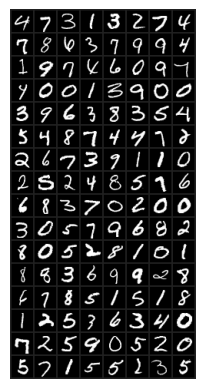

Rótulos:  4 7 3 1 3 2 7 4 7 8 6 3 7 9 9 4 1 9 7 4 6 0 9 7 4 0 0 1 3 9 0 0 3 9 6 3 8 3 5 4 5 4 8 7 4 4 7 2 2 6 7 3 9 1 1 0 2 5 2 4 8 5 7 6 6 8 3 7 0 2 0 0 3 0 5 7 9 6 8 2 8 0 5 2 8 1 0 1 8 8 3 6 9 9 2 8 6 7 8 5 1 5 1 8 1 2 5 3 6 3 4 0 7 2 5 9 0 5 2 0 5 7 1 5 5 2 3 5


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Função para exibir uma imagem
def imshow(img):
    # A normalização precisa ser revertida para a visualização correta
    # Média = 0.1307, Desvio Padrão = 0.3081
    img = img * 0.3081 + 0.1307 
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off') # Remove os eixos
    plt.show()

# Pega um lote (batch) de imagens de treino
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Mostra as imagens em uma grade
# O make_grid organiza o lote de imagens em uma única imagem-grade
imshow(torchvision.utils.make_grid(images))

# Imprime os rótulos correspondentes
print('Rótulos: ', ' '.join(f'{labels[j].item()}' for j in range(batch_size)))

## Funções de Custo (Loss Functions)

A função de custo $J(\theta)$ mede a discrepância entre a saída prevista pelo modelo $\hat{y}$ e o valor real $y$. O objetivo do treinamento é encontrar os parâmetros $\theta$ que minimizam $J(\theta)$.

### Funções Comuns

-   **Mean Squared Error (MSE)**: Utilizada principalmente para tarefas de regressão. Calcula a média dos erros quadráticos entre a previsão e o valor real.
    $$ J_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$
-   **Binary Cross-Entropy (BCE)**: Utilizada para classificação binária. Geralmente é combinada com uma camada de saída Sigmoid.
    $$ J_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right] $$
-   **Cross-Entropy Loss**: Utilizada para classificação multiclasse. No PyTorch, `nn.CrossEntropyLoss` combina `nn.LogSoftmax` e `nn.NLLLoss`, sendo numericamente mais estável. Ela espera como entrada os *logits* brutos do modelo e os rótulos de classe como inteiros.
    $$ J_{CE} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{i,c} \log(\hat{p}_{i,c}) $$
    Onde $y_{i,c}$ é 1 se a amostra $i$ pertence à classe $c$ (0 caso contrário), e $\hat{p}_{i,c}$ é a probabilidade prevista pelo modelo para a amostra $i$ pertencer à classe $c$.

In [12]:
# Instanciando a função de custo para classificação multiclasse
loss_function = nn.CrossEntropyLoss()

# Exemplo de uso:
# Saída do modelo (logits) para um batch de 3 amostras e 10 classes
output_logits = torch.randn(3, 10)
# Rótulos verdadeiros
target_labels = torch.tensor([1, 4, 9]) # Classe 1, Classe 4, Classe 9

# Calculando a perda
loss = loss_function(output_logits, target_labels)
print(f"Valor da perda (loss): {loss.item()}")

Valor da perda (loss): 2.791130781173706


## Otimizadores

O otimizador implementa o algoritmo de atualização dos parâmetros do modelo, $\theta$, com base nos gradientes da função de custo, $\nabla_{\theta} J(\theta)$. O objetivo é convergir para um mínimo (local ou global) da função de custo.

O algoritmo mais fundamental é o **Stochastic Gradient Descent (SGD)**. A regra de atualização para um parâmetro $\theta$ no passo de tempo $t$ é definida como:
$$
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} J(\theta_t)
$$
onde $\eta$ é a taxa de aprendizado (*learning rate*), um hiperparâmetro que controla o tamanho do passo na direção do gradiente negativo.

Otimizadores mais avançados, como o **Adam (Adaptive Moment Estimation)**, utilizam taxas de aprendizado adaptativas para cada parâmetro, mantendo uma estimativa do primeiro momento (a média) e do segundo momento (a variância não centrada) dos gradientes, o que frequentemente leva a uma convergência mais rápida.

In [18]:
# Instanciando o modelo
learning_rate = 0.001
model = NeuralNetwork(input_size=784, hidden_size=128, num_classes=10)

# Instanciando o otimizador Adam
# Passamos os parâmetros do modelo que devem ser otimizados (model.parameters()) e a taxa de aprendizado.
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# O otimizador possui métodos cruciais:
# optimizer.zero_grad(): Zera os gradientes de todos os parâmetros antes de um novo cálculo de backward pass. Isto é necessário porque o método .backward() acumula os gradientes por padrão.

# optimizer.step(): Atualiza os parâmetros do modelo usando a lógica do otimizador (e.g., Adam) e os gradientes armazenados no atributo .grad de cada parâmetro.

## Treinamento: O Ciclo Completo

O treinamento de uma rede neural consiste em um loop que itera sobre o dataset por várias "épocas" (*epochs*). Uma época é uma passagem completa por todo o dataset de treinamento. Dentro de cada época, iteramos sobre os *batches* de dados.

Para cada *batch*, o ciclo de treinamento é:
1.  **Zerar os gradientes**: Chamar `optimizer.zero_grad()`.
2.  **Forward Pass**: Passar os dados de entrada pelo modelo para obter as previsões (logits).
3.  **Calcular a Perda**: Comparar as previsões com os rótulos verdadeiros usando a função de custo.
4.  **Backward Pass**: Chamar `loss.backward()` para calcular os gradientes da perda em relação a cada parâmetro do modelo.
5.  **Atualizar os Pesos**: Chamar `optimizer.step()` para que o otimizador atualize os pesos com base nos gradientes.

In [16]:
# Hiperparâmetros
num_epochs = 5
input_size = 784 # 28x28
hidden_size = 500
num_classes = 10
learning_rate = 0.001

In [19]:
# Instanciando o modelo, função de custo e otimizador e movendo o modelo para o dispositivo
model = NeuralNetwork(input_size, hidden_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [20]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):

    # Treino
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)

    # Validação
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1} Val"):
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = outputs.argmax(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_losses.append(val_loss / len(test_loader))
    val_accuracies.append(100 * correct / total)

    print(
        f"Epoch {epoch+1} | "
        f"Train loss {train_losses[-1]:.4f}, acc {train_accuracies[-1]:.2f}% | "
        f"Val loss {val_losses[-1]:.4f}, acc {val_accuracies[-1]:.2f}%"
    )

Epoch 1 Train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1 | Train loss 0.2354, acc 93.06% | Val loss 0.1122, acc 96.74%


Epoch 2 Train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2 Val:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 4 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 4 | Train loss 0.0420, acc 98.69% | Val loss 0.0741, acc 97.49%


Epoch 5 Train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5 Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 5 | Train loss 0.0314, acc 99.02% | Val loss 0.0685, acc 98.01%


### Visualização das Curvas de Aprendizado

As curvas de aprendizado plotam as métricas de desempenho (como perda e acurácia) para os conjuntos de treinamento e validação ao longo das épocas. Elas são ferramentas de diagnóstico essenciais:

-   **Curva de Perda (Loss Curve)**: Mostra a evolução da função de custo. Idealmente, ambas as perdas (treino e validação) devem diminuir. Se a perda de validação começar a aumentar enquanto a de treino continua caindo, é um sinal claro de *overfitting*.
-   **Curva de Acurácia (Accuracy Curve)**: Mostra a evolução da acurácia. Idealmente, ambas devem aumentar e convergir. Uma grande diferença entre a acurácia de treino e a de validação também indica *overfitting*.

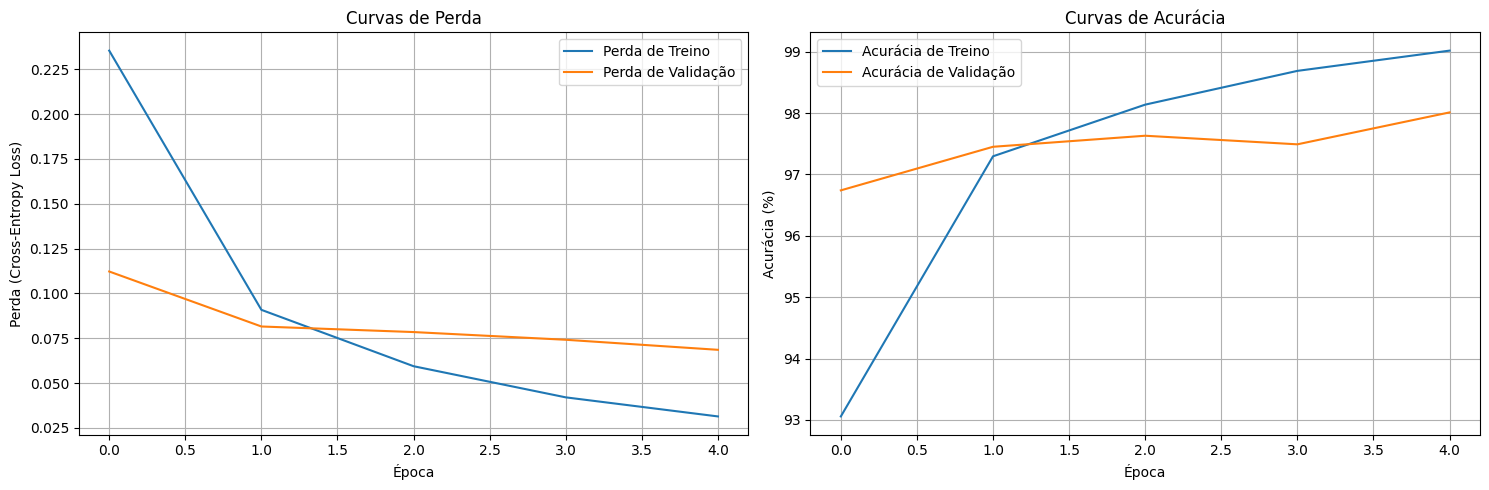

In [21]:
# Criando os plots
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot da Curva de Perda
axs[0].plot(train_losses, label='Perda de Treino')
axs[0].plot(val_losses, label='Perda de Validação')
axs[0].set_title("Curvas de Perda")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("Perda (Cross-Entropy Loss)")
axs[0].legend()
axs[0].grid(True)

# Plot da Curva de Acurácia
axs[1].plot(train_accuracies, label='Acurácia de Treino')
axs[1].plot(val_accuracies, label='Acurácia de Validação')
axs[1].set_title("Curvas de Acurácia")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Acurácia (%)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Avaliação do Modelo

Após o treinamento, é fundamental avaliar a performance do modelo em dados que ele nunca viu, ou seja, o conjunto de teste. Durante a avaliação, não precisamos calcular gradientes, o que economiza memória e computação. Para isso, usamos o contexto `torch.no_grad()`.

In [22]:
# Colocando o modelo em modo de avaliação (desativa camadas como Dropout, se houver)
model.eval()

# O contexto torch.no_grad() desabilita o cálculo de gradientes
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # A classe com o maior logit é a previsão
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Acurácia do modelo no dataset de teste: {100 * correct / total:.2f} %')

Acurácia do modelo no dataset de teste: 98.01 %
